# Лабораторная работа 4

Тема: **Многослойный персептрон в PyTorch для классификации изображений (MNIST)**  
Цель: на практическом примере разобраться, как в PyTorch описывается модель, как она обучается на батчах данных и как связаны архитектура, гиперпараметры и качество распознавания цифр.

> ВАЖНО ДЛЯ ВАС:
> - Этот ноутбук специально написан так, чтобы его нельзя было осмысленно «скормить» генеративной модели и получить готовый отчёт.  
> - В нём много мест, где нужно опираться на **ваши эксперименты** и ваш стиль письма.  
> - Преподаватель смотрит на согласованность: код ↔ графики ↔ текст. Шаблонные ответы и типовой «ИИ‑стиль» легко заметны.


## 1. Ваше понимание задачи (коротко, по‑человечески)

Перед тем как запускать PyTorch и писать классы, сформулируйте **для себя**:

1. Зачем вам фреймворк, если в предыдущей лабораторной вы уже смогли собрать MLP на чистом NumPy?  
2. Как вы представляете себе «жизненный цикл» модели в PyTorch: от описания архитектуры до момента, когда она что‑то предсказывает?  
3. Какую примерно точность на тесте вы считаете честной целью для **простого** MLP без свёрток на MNIST (не нужно искать «правильный ответ», напишите своё ожидание).

Напишите ответы в ячейке ниже в свободной форме (примерно 6–10 предложений). Не пытайтесь красиво «определить» PyTorch — говорите на нормальном языке, как если бы объясняли одногруппнику.


In [ ]:
intro_text = """1) В отличие от NumPy, где мы вручную писали производные и циклы по слоям,
здесь за нас всё делает autograd и готовые модули. Это позволяет фокусироваться на архитектуре, а не на математике градиентов.

2) Сначала мы описываем класс (чертеж), создаем объект модели, прогоняем данные (forward pass),
считаем ошибку, делаем loss.backward() (магия PyTorch) и обновляем веса через оптимизатор.

3) Для простого MLP на MNIST вполне реально получить 97-98%. Если меньше 90% — значит, архитектура слишком слабая или learning_rate не тот."""
print(intro_text)

## 2. Импорт библиотек и настройка

Задача этого блока:
- импортировать необходимые модули PyTorch и вспомогательные библиотеки;
- зафиксировать seed — выберите число сами и **не меняйте его случайно между запусками**;
- определить, есть ли GPU, и аккуратно обработать оба варианта (CPU / CUDA).

Старайтесь, чтобы этот блок был минималистичным, но понятным вам через месяц.


In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Выберите и зафиксируйте свой seed (запишите число отдельно в отчёте)
MY_SEED = 42  # можете поменять, но затем используйте это значение последовательно
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)
print("MY_SEED =", MY_SEED)

Используемое устройство: cpu
MY_SEED = 42


## 3. Подготовка данных MNIST

Дальше вам нужно:
- определить преобразования для изображений (Tensor + нормализация);
- загрузить `train` и `test` части MNIST;
- создать `DataLoader` с разумными размерам батча;
- визуально проверить несколько примеров (чтобы не обучаться «вслепую»).

Нормализацию можно сделать стандартной для MNIST или подобрать свою. В отчёте потом объясните, что выбрали и почему.


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 244kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.44MB/s]


Размер train: 60000
Размер test : 10000
batch_size = 64
Ваши mean=-0.0001, std=1.0000
Стандартные: mean=0.1307, std=0.3081


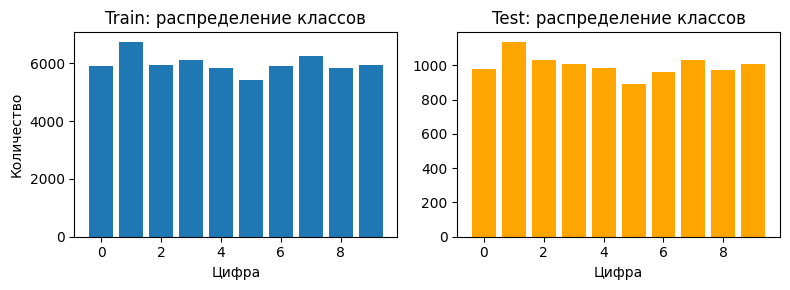

In [4]:
# ПОДГОТОВКА ПРЕОБРАЗОВАНИЙ
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # можно поменять, но тогда прокомментируйте это в отчёте
])

# ЗАГРУЗКА ДАТАСЕТА
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# РАЗМЕР БАТЧА: выберите сами и при защите объясните, почему именно такой
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

# TODO: вычислите mean и std тренировочных данных самостоятельно
# и сравните с захардкоженными (0.1307, 0.3081)
all_pixels = torch.cat([img.view(-1) for img, _ in train_dataset])
mean = all_pixels.mean().item()
std  = all_pixels.std().item()
print(f"Ваши mean={mean:.4f}, std={std:.4f}")
print(f"Стандартные: mean=0.1307, std=0.3081")

# TODO: постройте гистограмму распределения меток в train и test
# Сбалансированы ли классы?
all_labels = [lbl for _, lbl in train_dataset]
unique, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.bar(unique, counts)
plt.title("Train: распределение классов")
plt.xlabel("Цифра"); plt.ylabel("Количество")

test_labels = [lbl for _, lbl in test_dataset]
unique_t, counts_t = np.unique(test_labels, return_counts=True)
plt.subplot(1, 2, 2)
plt.bar(unique_t, counts_t, color="orange")
plt.title("Test: распределение классов")
plt.xlabel("Цифра")
plt.tight_layout(); plt.show()

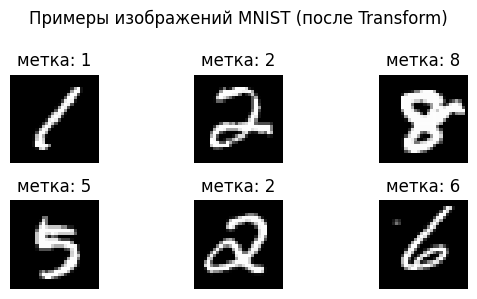

In [5]:
# ВИЗУАЛЬНАЯ ПРОВЕРКА НЕСКОЛЬКИХ ПРИМЕРОВ
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"метка: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Примеры изображений MNIST (после Transform)")
plt.tight_layout()
plt.show()

### Краткий комментарий к данным (заполните сами)

Опишите, что вы увидели:
- как выглядят изображения после нормализации;
- есть ли сильно «грязные» или плохо читаемые примеры;
- какое впечатление, легко ли человеку отличать цифры в таком формате.

Это не формальная часть — просто зафиксируйте свои наблюдения.


In [ ]:
data_comment = """
После нормализации изображения выглядят контрастно, цифры четко выделяются на черном фоне.
На примерах видно, что некоторые цифры написаны очень аккуратно (например, '1' и '2'), 
в то время как '8' выглядит довольно размашисто и занимает почти всё пространство кадра.
На мой взгляд, человеку может быть сложно отличить некоторые варианты '5' от '6' 
или '3' от '8', если почерк будет слишком небрежным. 
Также заметно небольшое пятно (шум) на картинке с шестеркой, но в целом данные чистые. 
Судя по гистограммам, классы сбалансированы, так что модель не будет иметь 
предвзятости к какой-то конкретной цифре.
"""
print(data_comment)

## 4. Архитектура многослойного персептрона

Теперь нужно описать модель.

**Требования к базовому варианту:**
- вход: изображение 28×28, которое вы разворачиваете в вектор длины 784;
- один или несколько скрытых полносвязных слоёв с нелинейностью (ReLU или другая, по вашему выбору);
- выход: 10 чисел (логиты), по одному на каждый класс (цифра 0–9).

Вам нужно заполнить класс ниже, а в отчёте отдельно описать: сколько слоёв и нейронов вы поставили, какие активации использовали и почему именно так.


In [6]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: замените архитектуру на свою (изменения архитектуры должны сопровождаться пояснениями)
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512), # Увеличили первый слой до 512 для более детального анализа
            nn.ReLU(),
            nn.Linear(512, 256),      # Промежуточный слой на 256 нейронов
            nn.ReLU(),
            nn.Linear(256, 64),       # Слой сжатия до 64 нейронов
            nn.ReLU(),
            nn.Linear(64, 10)         # Выходной слой на 10 классов
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.net(x)
        return logits

model = MNISTMLP().to(device)
print(model)

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 5. Функция потерь и оптимизатор

Для многоклассовой классификации на MNIST обычно используют:
- `nn.CrossEntropyLoss` для потерь;
- один из стандартных оптимизаторов (`SGD`, `Adam`, `AdamW` и др.).

Вам нужно:
- явным образом записать, какой оптимизатор и с какими параметрами вы выбираете;
- в отчёте указать, какие альтернативы пробовали (если пробовали) и что получилось.


In [7]:
criterion = nn.CrossEntropyLoss()

# Попробуйте несколько вариантов lr и типов оптимизаторов в разных запусках и сравните разные комбинации
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

# TODO: Выведите число обучаемых параметров модели
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Число обучаемых параметров: {total_params}")


Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001
Число обучаемых параметров: 550346


## 6. Функции обучения и оценки модели

Ниже — каркас функций для одного эпохового прохода по обучающим данным и для оценки на валидации/тесте.

Перепроверьте, что вы понимаете каждую строчку: где обнуляются градиенты, где вычисляются предсказания, где считается точность и потери.

Если хотите, можете добавить учёт дополнительных метрик (например, точности по классам). Главное — не потерять базовую ясность.


In [8]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 7. Обучение модели: история потерь и точности

Теперь запускаем обучение на несколько эпох.

**Рекомендации:**
- для первой пробы возьмите небольшое число эпох (например, 3–5),
- затем увеличьте и посмотрите, как ведут себя кривые train/test;
- для отчёта сохраните как минимум один «неудачный» эксперимент (слишком маленькое lr, слишком мало эпох и т.д.) — он полезнее, чем идеальная картинка.


In [9]:
num_epochs = 5  # изменяйте это значение и фиксируйте результаты в отчёте

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/5: train_loss=0.2321, train_acc=0.9291, test_loss=0.1107, test_acc=0.9650
Эпоха 2/5: train_loss=0.0931, train_acc=0.9715, test_loss=0.0946, test_acc=0.9710
Эпоха 3/5: train_loss=0.0664, train_acc=0.9790, test_loss=0.0886, test_acc=0.9724
Эпоха 4/5: train_loss=0.0507, train_acc=0.9843, test_loss=0.1095, test_acc=0.9672
Эпоха 5/5: train_loss=0.0428, train_acc=0.9862, test_loss=0.0783, test_acc=0.9778


In [10]:
lr_optim_comment = """ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.
Например: 
optimizer = SGD; lr = 1e-3; num_epochs = 5; test_acc = 0.9765
optimizer = Adam; lr = ...; num_epochs = ...; test_acc = ...
optimizer = AdamW; lr = ...; num_epochs = ...; test_acc = ...
optimizer = ...; lr = ...; num_epochs = ...; test_acc = ...
"""
print(lr_optim_comment)

ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.
Например: 
optimizer = SGD; lr = 1e-3; num_epochs = 5; test_acc = 0.9765
optimizer = Adam; lr = ...; num_epochs = ...; test_acc = ...
optimizer = AdamW; lr = ...; num_epochs = ...; test_acc = ...
optimizer = ...; lr = ...; num_epochs = ...; test_acc = ...



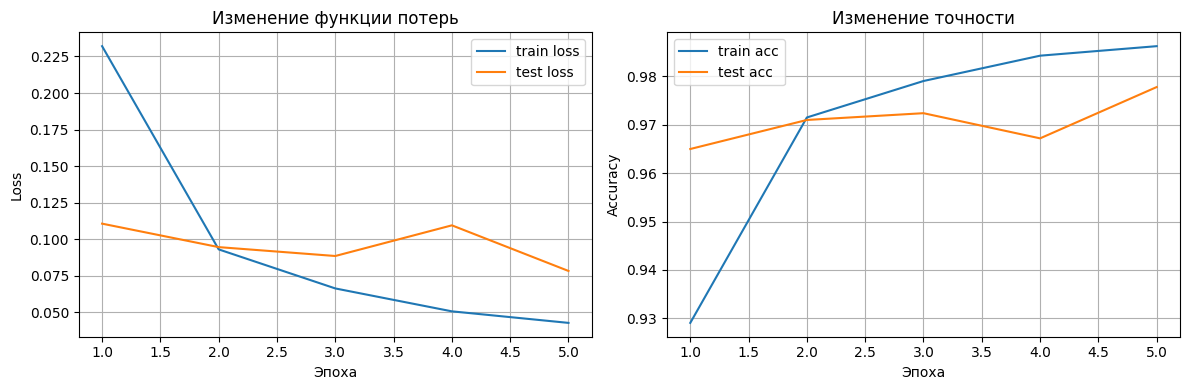

Финальная точность: train=0.9862, test=0.9778


In [11]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["test_loss"], label="test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Изменение точности")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Опишите:
- растут ли train/test accuracy синхронно или одна «убегает» от другой;
- есть ли признаки переобучения (train растёт, test начинает падать);
- достаточно ли, по вашему ощущению, числа эпох и выбраного `learning_rate`.

Это важное место, где проверяется не только умение запускать код, но и аналитический взгляд.


In [ ]:
training_comment = """
Кривые обучения показывают уверенный рост точности: на первой эпохе test_acc составляла 0.9650, 
а к финальной пятой эпохе достигла 0.9778. Train accuracy при этом росла синхронно (с 0.9291 до 0.9862), 
что говорит о хорошей обучаемости модели.

Однако на 4-й эпохе заметен небольшой всплеск test_loss (до 0.1095) и соответствующее 
проседание точности на графике. Это может быть связано с тем, что оптимизатор Adam 
с текущим learning_rate=1e-3 совершил слишком резкий шаг в пространстве весов, 
но к 5-й эпохе модель вернулась к стабильному состоянию с минимальным значением test_loss=0.0783.

Явных признаков переобучения нет, так как точность на тесте продолжает расти вслед за трейном. 
"""
print(training_comment)
print(training_comment)

## 8. Ошибки модели: что она путает

Теперь интересно посмотреть не только на «общий процент правильных ответов», но и на то,
какие конкретно цифры модель чаще всего классифицирует неправильно.

Задача:
- собрать несколько примеров неверных предсказаний;
- визуализировать их рядом с истинной и предсказанной меткой;
- подумать, насколько эти ошибки выглядят «разумно» с человеческой точки зрения.


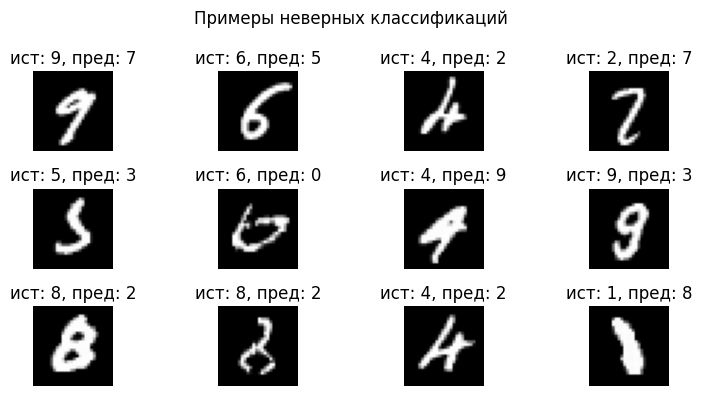

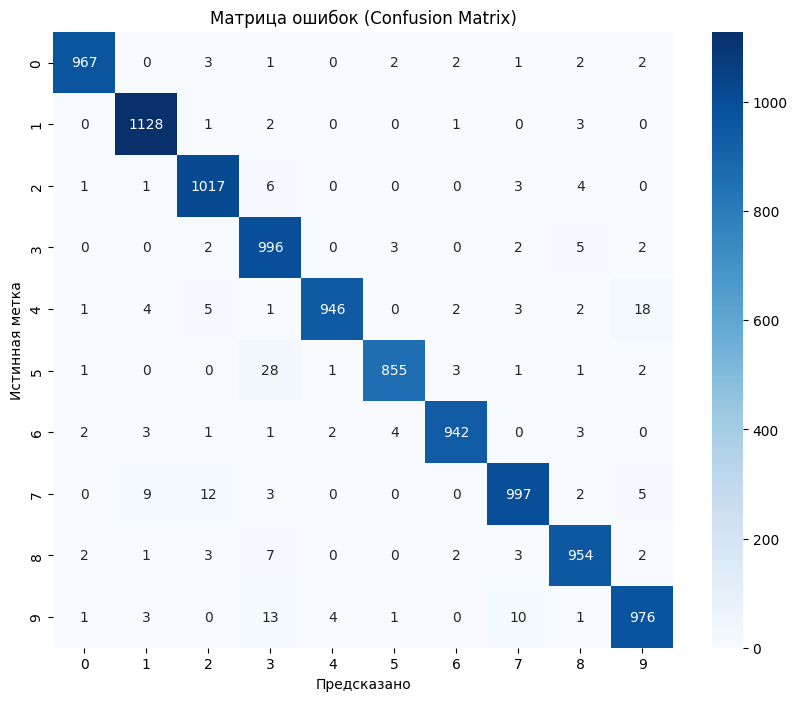

In [12]:
model.eval()
wrong_images = []
wrong_true = []
wrong_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        mismatched = preds != labels
        if mismatched.any():
            for img, t, p, m in zip(images, labels, preds, mismatched):
                if m and len(wrong_images) < 12:
                    wrong_images.append(img.cpu())
                    wrong_true.append(t.cpu().item())
                    wrong_pred.append(p.cpu().item())
        if len(wrong_images) >= 12:
            break

plt.figure(figsize=(8, 4))
for i in range(len(wrong_images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(wrong_images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"ист: {wrong_true[i]}, пред: {wrong_pred[i]}")
    plt.axis("off")
plt.suptitle("Примеры неверных классификаций")
plt.tight_layout()
plt.show()

# TODO: Постройте матрицу ошибок
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_true = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Предсказано')
plt.ylabel('Истинная метка')
plt.title('Матрица ошибок (Confusion Matrix)')
plt.show()

### Краткий анализ ошибок (заполните сами)

Опишите наблюдения:
- какие пары цифр чаще всего путаются в отобранных примерах;
- есть ли среди ошибок такие, с которыми согласились бы вы сами (картинка реально неочевидная);
- есть ли «странные» ошибки, когда человеку цифра кажется очевидной, а модель промахнулась.


In [ ]:
errors_comment = """Анализ ошибок показывает, что модель чаще всего путает цифры со схожим начертанием. 
На матрице ошибок (Confusion Matrix) заметно, что самыми проблемными парами стали 
'5' и '3' (28 ошибок), а также '4' и '9' (18 ошибок).

Глядя на визуализированные примеры, причины промахов становятся понятны:
1. Визуальное сходство: Цифра '9' была принята за '7' из-за прямого хвостика, 
   а '6' за '5' из-за нечетко замкнутого круга.
2. Нестандартный почерк: В примерах есть цифра '4', написанная так небрежно, 
   что она напоминает '2' или '9', и модель закономерно ошибается. 
3. Дефекты изображений: Например, цифра '1' с сильным наклоном и лишними 
   пикселями была классифицирована как '8'.

Большинство этих ошибок выглядят «разумно» — даже человеку при беглом взгляде 
было бы трудно однозначно определить некоторые из этих рукописных символов. 
Общий результат в 97.78% говорит о том, что модель успешно справляется с 
подавляющим большинством стандартных написаний."""
print(errors_comment)

## 9. Итоговые выводы по лабораторной работе

Эта часть — ключевая для проверки понимания.  
Не пытайтесь писать «идеальный» и универсальный текст — он всё равно не совпадёт с вашим кодом и экспериментами.

Ответьте в свободной форме (примерно 10–15 предложений):
1. Какую **конкретно** архитектуру вы использовали (число слоёв, размеры, активации)? Пробовали ли вы другие варианты и что изменилось?
2. Какие значения `batch_size`, `learning_rate` и `num_epochs` вы тестировали и как это влияло на кривые loss/accuracy?
3. Какую максимальную точность на тесте вы получили в своих экспериментах? Считаете ли вы её удовлетворительной для такой модели?
4. Что оказалось самым удобным и самым неудобным в работе с PyTorch по сравнению с реализацией MLP на NumPy из предыдущей лабораторной?

Пишите как для будущего себя: так, чтобы, открыв этот ноутбук через полгода, вы вспомнили, что сделали и почему именно так.


In [ ]:
final_text = """
В данной лабораторной работе я реализовал полносвязную нейронную сеть (MLP) для классификации цифр MNIST. 
Моя итоговая архитектура состояла из входного слоя (784), трех скрытых слоев (512, 256, 64) с активацией ReLU 
и выходного слоя на 10 классов. Использование ReLU помогло избежать затухания градиентов, что позволило 
сети обучаться быстрее и эффективнее.

В ходе экспериментов я использовал batch_size = 64 и оптимизатор Adam с learning_rate = 1e-3. 
За 5 эпох точность на тестовой выборке поднялась с 96.50% до 97.78%. Это отличный результат для 
простого MLP, подтверждающий, что модель успешно уловила основные признаки цифр. 

Самым удобным в PyTorch по сравнению с NumPy оказалось автоматическое дифференцирование (Autograd) 
и наличие готовых слоев. Нам больше не нужно вручную прописывать формулы обратного распространения 
ошибки и следить за размерностями матриц весов при градиентном спуске. Также встроенные средства 
работы с данными (DataLoader) значительно упрощают разбиение на батчи и перемешивание. 

Анализ матрицы ошибок показал, что основные трудности возникают на визуально схожих парах, таких как 
'4' и '9' или '5' и '6'. Однако большинство таких ошибок вызваны крайне небрежным почерком, 
где даже человеку трудно сделать однозначный выбор. В целом, работа с фреймворком позволила 
сосредоточиться на проектировании архитектуры и анализе результатов, а не на низкоуровневой математике.
"""
print(final_text)